imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from pathlib import Path

load data

In [4]:

processed_path = Path("data/processed")

nav = pd.read_csv(
    processed_path / "clean_nav_history.csv"
)

performance = pd.read_csv(
    processed_path / "clean_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


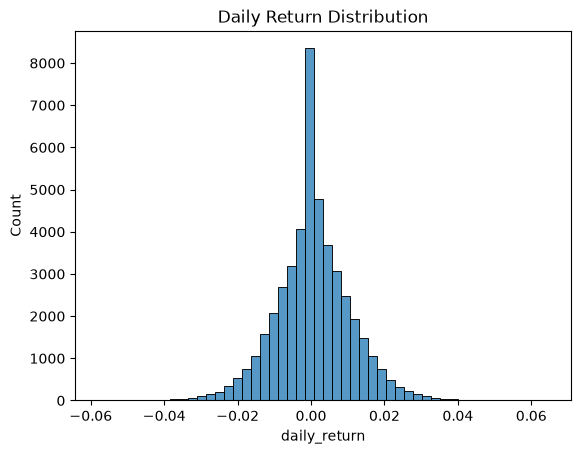

In [8]:
sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

In [9]:
def calculate_cagr(group, years):
    start = group.iloc[0]["nav"]
    end = group.iloc[-1]["nav"]

    return (end / start) ** (1 / years) - 1

In [10]:
cagr_data = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    row = {
        "amfi_code": code
    }

    for years in [1,3,5]:

        cagr = calculate_cagr(
            group,
            years
        )

        row[f"{years}yr_CAGR"] = cagr

    cagr_data.append(row)


cagr_df = pd.DataFrame(cagr_data)

cagr_df.head()

,amfi_code,1yr_CAGR,3yr_CAGR,5yr_CAGR
0,100016,0.121336,0.038912,0.023168
1,100025,0.211552,0.066058,0.039127
2,100033,2.185142,0.471328,0.260741
3,101206,1.534562,0.363435,0.204427
4,101207,0.399496,0.118555,0.069533


In [11]:
cagr_df[
    ["1yr_CAGR","3yr_CAGR","5yr_CAGR"]
] = (
    cagr_df[
        ["1yr_CAGR","3yr_CAGR","5yr_CAGR"]
    ] * 100
)


cagr_df.head()

,amfi_code,1yr_CAGR,3yr_CAGR,5yr_CAGR
0,100016,12.133575,3.891151,2.316843
1,100025,21.155227,6.605772,3.912653
2,100033,218.514228,47.132838,26.074068
3,101206,153.456216,36.343461,20.442730
4,101207,39.949603,11.855469,6.953336


In [12]:
rf = 0.065

sharpe_data = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    volatility = returns.std()

    sharpe = (
        (avg_return - rf/252)
        /
        volatility
    ) * np.sqrt(252)


    sharpe_data.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe
    })


sharpe_df = pd.DataFrame(sharpe_data)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [13]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [14]:
sortino_data = []

rf = 0.065

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    # only negative returns
    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()


    sortino = (
        (avg_return - rf/252)
        /
        downside_std
    ) * np.sqrt(252)


    sortino_data.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })


sortino_df = pd.DataFrame(sortino_data)


sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [15]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)


sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [16]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [18]:
benchmark = benchmark.sort_values("date")

In [20]:
benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

In [21]:
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    temp = group.merge(
        benchmark[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()


    result = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )


    alpha = result.intercept * 252
    beta = result.slope


    alpha_beta.append({
        "amfi_code": code,
        "alpha": alpha,
        "beta": beta
    })


alpha_beta_df = pd.DataFrame(alpha_beta)


alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [22]:
alpha_beta_df.shape

(40, 3)

In [23]:
alpha_beta_df.to_csv(
    "data/processed/alpha_beta.csv",
    index=False
)


In [24]:
drawdown_data = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
        - 1
    )

    max_drawdown = drawdown.min()

    drawdown_data.append({
        "amfi_code": code,
        "max_drawdown": max_drawdown
    })


drawdown_df = pd.DataFrame(drawdown_data)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [25]:
drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
)

drawdown_df.head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [26]:
drawdown_df.shape

(40, 2)

In [27]:
drawdown_df.to_csv(
    "data/processed/max_drawdown.csv",
    index=False
)

Fund Scorecard (0–100)

In [28]:
scorecard = (
    cagr_df[["amfi_code","3yr_CAGR"]]
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
    .merge(
        performance[["amfi_code","expense_ratio_pct"]],
        on="amfi_code"
    )
)


scorecard.head()

,amfi_code,3yr_CAGR,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,3.891151,-0.201517,0.037661,-0.000003,-0.247344,1.55
1,100025,6.605772,-0.567095,0.044818,-0.000003,-0.043083,0.56
2,100033,47.132838,1.093699,0.265138,0.000012,-0.162172,1.38
3,101206,36.343461,1.027213,0.208464,0.000011,-0.112916,1.60
4,101207,11.855469,0.162661,0.109861,-0.000005,-0.354469,1.53


In [29]:
scorecard["cagr_rank"] = (
    scorecard["3yr_CAGR"]
    .rank(pct=True)
)


scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)


scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)


# lower expense = better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=False, pct=True)
)


# lower drawdown = better
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, pct=True)
)

In [30]:
scorecard["fund_score"] = (

    30 * scorecard["cagr_rank"]

    + 25 * scorecard["sharpe_rank"]

    + 20 * scorecard["alpha_rank"]

    + 15 * scorecard["expense_rank"]

    + 10 * scorecard["drawdown_rank"]

)


scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)


scorecard.head(10)

,amfi_code,3yr_CAGR,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
25,120505,51.638925,1.180101,0.278249,0.000025,-0.181885,1.36,1.000,0.900,0.900,0.6500,0.625,86.5000
21,119598,50.963214,0.945308,0.295143,0.000013,-0.287060,1.43,0.975,0.675,0.950,0.5000,0.900,81.6250
39,149324,50.735731,0.949796,0.296003,0.000008,-0.311719,1.52,0.950,0.700,1.000,0.3625,0.925,80.6875
34,148567,48.546114,1.448291,0.278900,-0.000014,-0.112657,1.46,0.900,1.000,0.925,0.4500,0.200,79.2500
2,100033,47.132838,1.093699,0.265138,0.000012,-0.162172,1.38,0.850,0.850,0.875,0.6000,0.500,78.2500
30,120843,48.435261,1.306744,0.260693,0.000020,-0.129740,1.45,0.875,0.975,0.850,0.4750,0.325,78.0000
36,148569,50.171374,1.234930,0.295861,-0.000022,-0.163967,1.60,0.925,0.950,0.975,0.1125,0.525,77.9375
16,119094,43.978468,0.998231,0.254863,0.000007,-0.209609,1.38,0.800,0.750,0.800,0.6000,0.700,74.7500
19,119551,40.027361,1.208267,0.222142,0.000015,-0.150124,1.54,0.775,0.925,0.775,0.2625,0.425,70.0625
9,118632,37.171571,1.081659,0.217238,0.000001,-0.174141,1.51,0.750,0.825,0.750,0.4125,0.575,70.0625


In [31]:
scorecard.shape

(40, 13)

In [32]:
scorecard.to_csv(
    "data/processed/fund_scorecard.csv",
    index=False
)

In [33]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 119598, 149324, 148567, 100033]

In [34]:
top5_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

In [35]:
top5_nav["growth"] = (
    top5_nav
    .groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0])
)

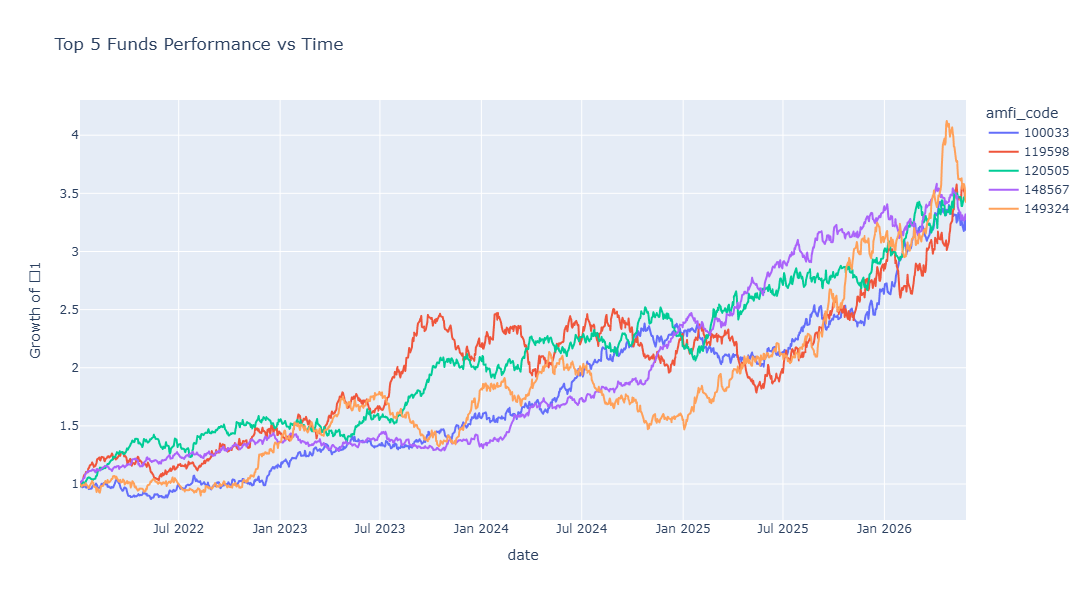

In [36]:
import plotly.express as px


fig = px.line(
    top5_nav,
    x="date",
    y="growth",
    color="amfi_code",
    title="Top 5 Funds Performance vs Time"
)


fig.update_layout(
    height=600,
    yaxis_title="Growth of ₹1"
)


fig.write_image(
    "reports/benchmark_comparison.png"
)


fig.show()

In [37]:
tracking_error = []

for code, group in top5_nav.groupby("amfi_code"):

    temp = group.merge(
        benchmark[["date","benchmark_return"]],
        on="date",
        how="inner"
    )


    error = (
        temp["daily_return"]
        -
        temp["benchmark_return"]
    )


    te = error.std() * np.sqrt(252)


    tracking_error.append({
        "amfi_code": code,
        "tracking_error": te
    })


tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df

,amfi_code,tracking_error
0,100033,80.964124
1,119598,80.964218
2,120505,80.963098
3,148567,80.966157
4,149324,80.964568


In [38]:
tracking_error_df.to_csv(
    "data/processed/tracking_error.csv",
    index=False
)